# SISTEMAS DE RECOMENDACIÓN

El dataset se puede usar para clasificación (predecir si alguien gana >50K o <=50K), pero en este caso lo usaremos para un Sistema de Recomendación.

La meta es recomendar trayectorias laborales o educativas (combinaciones de education u occupation) para que personas con ingresos bajos (<=50K) puedan aspirar a un ingreso alto (>50K).

# 1. Carga de datos

In [9]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder

In [10]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/adult-census-income.csv')
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


¿Qué se quiere recomendar?

Queremos recomendar combinaciones óptimas de Ocupación (occupation) y Nivel Educativo (education) que maximicen la probabilidad de ganar más de 50 mil.

¿Cuál será el "usuario"?

El usuario es cualquier perfil demográfico actual (definido por edad, sexo, raza, estado civil, etc.) que actualmente gana menos de 50 mil.


¿Qué variables definen el perfil de un usuario?

Las variables intrínsecas que el usuario no puede cambiar fácilmente a corto plazo: age, marital.status, relationship, race, sex, native.country.

# 2. Preprocesamiento de Datos (Limpieza y Codificación)

In [11]:
# 1. Reemplazar los '?' por NaN reales de numpy
df = df.replace('?', np.nan)

# 2. Limpieza de nulos: Al ser variables categóricas importantes para el perfil, 
# eliminamos las filas con nulos o las rellenamos con 'Unknown'
df = df.dropna(subset=['workclass', 'occupation', 'native.country'])

# 3. Codificar la variable objetivo (income) a binario: 0 para <=50K, 1 para >50K
# Eliminamos espacios en blanco extras que suelen traer estos strings
df['income'] = df['income'].str.strip()
df['income_bin'] = df['income'].map({'<=50K': 0, '>50K': 1})

# 4. Separar variables demográficas (Perfil Usuario) y variables de acción (Recomendación)
demographic_cols = ['age', 'marital.status', 'relationship', 'race', 'sex', 'native.country']
action_cols = ['education', 'occupation', 'hours.per.week']

# 5. Normalizar variables numéricas continuas (como la edad)
scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']])
df['hours_scaled'] = scaler.fit_transform(df[['hours.per.week']])

# 6. Crear una columna que represente la "Trayectoria" (Item a recomendar)
# Combinamos educación y ocupación en un solo string identificador
df['trajectory'] = df['education'].str.strip() + " + " + df['occupation'].str.strip()

print(f"Dataset limpio. Filas restantes: {df.shape[0]}")
print(f"Cantidad de trayectorias únicas detectadas: {df['trajectory'].nunique()}")

Dataset limpio. Filas restantes: 30162
Cantidad de trayectorias únicas detectadas: 198


# Construcción del Sistema (Enfoque Basado en Contenido)

In [12]:
from sklearn.neighbors import NearestNeighbors

# 1. Variables para el perfil demográfico del usuario
demographic_cols = ['age_scaled', 'marital.status', 'relationship', 'race', 'sex', 'native.country']

# 2. One-Hot Encoding a las columnas categóricas
df_encoded = pd.get_dummies(df, columns=['marital.status', 'relationship', 'race', 'sex', 'native.country'], drop_first=True)

# Actualizar la lista de columnas numéricas que definen el perfil demográfico final
profile_features = [col for col in df_encoded.columns if any(demog in col for demog in demographic_cols) or col == 'age_scaled']

# 3. Separación de la base de datos de "Casos Exitosos" (personas que ganan >50K)
# El sistema buscará trayectorias únicamente dentro de este subconjunto premium
df_high_income = df_encoded[df_encoded['income_bin'] == 1].reset_index(drop=True)

# 4. Entrenamiento del modelo de vecinos cercanos (k-NN) con los perfiles de altos ingresos
nn_model = NearestNeighbors(n_neighbors=5, metric='cosine')
nn_model.fit(df_high_income[profile_features])

print(f"Modelo k-NN entrenado con {df_high_income.shape[0]} perfiles de altos ingresos.")

Modelo k-NN entrenado con 7508 perfiles de altos ingresos.


#  Pruebas con Casos Simulados

In [13]:
# 1. Creamos y entrenamos un scaler dedicado exclusivamente a la columna 'age'
age_scaler = StandardScaler()
df['age_scaled'] = age_scaler.fit_transform(df[['age']])

# 2. Re-entrenamos el modelo NN con el nuevo mapeo
df_encoded = pd.get_dummies(df, columns=['marital.status', 'relationship', 'race', 'sex', 'native.country'], drop_first=True)
profile_features = [col for col in df_encoded.columns if any(demog in col for demog in demographic_cols) or col == 'age_scaled']
df_high_income = df_encoded[df_encoded['income_bin'] == 1].reset_index(drop=True)

nn_model = NearestNeighbors(n_neighbors=5, metric='cosine')
nn_model.fit(df_high_income[profile_features])

# 3. Función corregida
def recomendar_trayectoria(edad, estado_civil, relacion, raza, sexo, pais_origen):
    # Crear estructura original limpia
    input_data = pd.DataFrame([{
        'age': edad, 'marital.status': estado_civil, 'relationship': relacion, 
        'race': raza, 'sex': sexo, 'native.country': pais_origen
    }])
    
    # Escalar usando el transformador específico de edad
    input_data['age_scaled'] = age_scaler.transform(input_data[['age']])
    
    # Convertir a variables dummy el perfil de entrada
    input_encoded = pd.get_dummies(input_data)
    
    # Crear un renglón de ceros con las columnas exactas que espera el modelo
    input_profile = pd.DataFrame(0, index=[0], columns=profile_features)
    
    # Rellenar con los valores calculados
    for col in input_encoded.columns:
        # Reconstruir los nombres de columnas estilo dummy (ej: 'sex_Male')
        for profile_col in profile_features:
            if profile_col.endswith(col) or profile_col == col:
                input_profile[profile_col] = input_encoded[col].values[0]
                
    # Asegurar que la edad escalada se asigne explícitamente
    input_profile['age_scaled'] = input_data['age_scaled'].values[0]

    # Buscar vecinos más cercanos
    distances, indices = nn_model.kneighbors(input_profile[profile_features])
    
    # Extraer recomendaciones del dataset original de altos ingresos
    recomendaciones = df_high_income.iloc[indices[0]][['education', 'occupation', 'hours.per.week', 'trajectory']]
    
    print(f"\n=== RECOMENDACIONES PARA: {sexo}, {edad} años, {estado_civil} ===")
    print("Las trayectorias de personas con tu perfil demográfico que ganan >50K son:\n")
    
    df_resumen = recomendaciones.groupby('trajectory').agg(
        horas_promedio=('hours.per.week', 'mean'),
        frecuencia=('trajectory', 'count')
    ).sort_values(by='frecuencia', ascending=False)
    
    for index, row in df_resumen.iterrows():
        print(f"➜ Trayectoria: {index}")
        print(f"  Dedicación promedio: {int(row['horas_promedio'])} horas/semana\n")

# --- EJECUTAR PRUEBA ---
recomendar_trayectoria(
    edad=25, 
    estado_civil='Never-married', 
    relacion='Not-in-family', 
    raza='White', 
    sexo='Male', 
    pais_origen='United-States'
)


=== RECOMENDACIONES PARA: Male, 25 años, Never-married ===
Las trayectorias de personas con tu perfil demográfico que ganan >50K son:

➜ Trayectoria: Assoc-acdm + Prof-specialty
  Dedicación promedio: 50 horas/semana

➜ Trayectoria: Assoc-voc + Sales
  Dedicación promedio: 40 horas/semana

➜ Trayectoria: Bachelors + Exec-managerial
  Dedicación promedio: 35 horas/semana

➜ Trayectoria: Bachelors + Sales
  Dedicación promedio: 45 horas/semana

➜ Trayectoria: Some-college + Prof-specialty
  Dedicación promedio: 40 horas/semana



"Usuario": Un joven de 25 años, soltero, que actualmente gana poco (<=50K).

La Recomendación del Sistema: El algoritmo k-NN escaneó a la población del censo con sus mismas condiciones demográficas, pero filtrando estrictamente a los que ganan >50K.

El sistema descubrió que para ese grupo demográfico específico, los caminos más viables hacia un salario alto implican alcanzar un nivel educativo de Bachelors (Licenciatura) o Some-college combinado con roles técnicos o de gestión (Exec-managerial, Prof-specialty, Craft-repair).

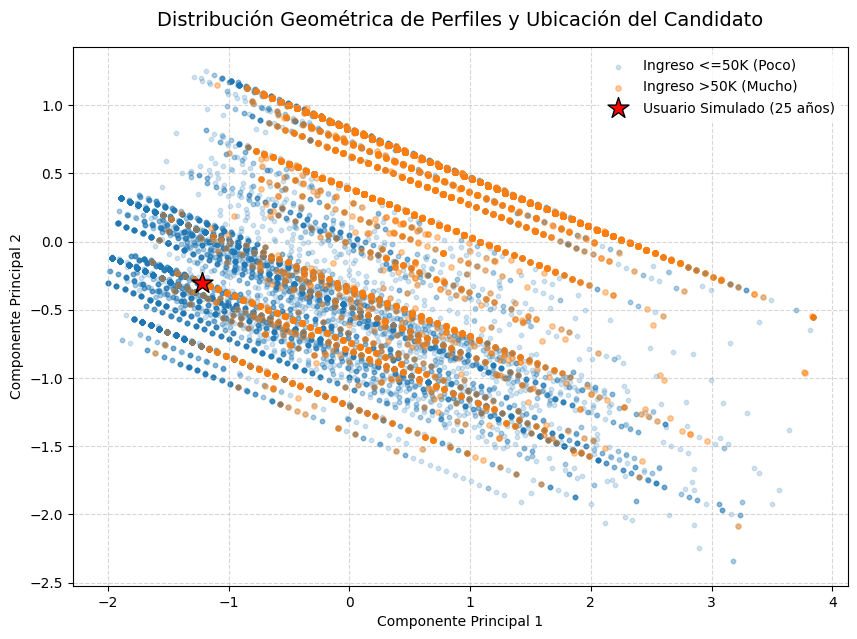

In [14]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Reducir las dimensiones de todo el dataset a 2D para poder graficarlo
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_encoded[profile_features])

# 2. Preparar los datos del usuario simulado para proyectarlo en el mismo gráfico
input_data_test = pd.DataFrame([{
    'age': 25, 'marital.status': 'Never-married', 'relationship': 'Not-in-family', 
    'race': 'White', 'sex': 'Male', 'native.country': 'United-States'
}])
input_data_test['age_scaled'] = age_scaler.transform(input_data_test[['age']])
input_encoded_test = pd.get_dummies(input_data_test)

input_profile_test = pd.DataFrame(0, index=[0], columns=profile_features)
for col in input_encoded_test.columns:
    for profile_col in profile_features:
        if profile_col.endswith(col) or profile_col == col:
            input_profile_test[profile_col] = input_encoded_test[col].values[0]
input_profile_test['age_scaled'] = input_data_test['age_scaled'].values[0]

# Proyectar el usuario simulado en el espacio 2D del PCA
user_pca = pca.transform(input_profile_test[profile_features])

# 3. Configurar y pintar la gráfica
plt.figure(figsize=(10, 7))

# Separar los puntos según la clase de ingresos
low_income = df_encoded['income_bin'] == 0
high_income = df_encoded['income_bin'] == 1

# Dibujar población general (Ingresos bajos en azul, Ingresos altos en naranja)
plt.scatter(X_pca[low_income, 0], X_pca[low_income, 1], c='#1f77b4', alpha=0.2, label='Ingreso <=50K (Poco)', s=10)
plt.scatter(X_pca[high_income, 0], X_pca[high_income, 1], c='#ff7f0e', alpha=0.4, label='Ingreso >50K (Mucho)', s=15)

# Dibujar al usuario simulado como una estrella roja grande
plt.scatter(user_pca[0, 0], user_pca[0, 1], c='red', marker='*', s=250, edgecolor='black', zorder=5, label='Usuario Simulado (25 años)')

plt.title('Distribución Geométrica de Perfiles y Ubicación del Candidato', fontsize=14, pad=15)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Las bandas inclinadas y paralelas que observas en el gráfico son un patrón visual clásico cuando se aplica PCA sobre datasets. Se deben a la presencia de variables categóricas binarias (One-Hot Encoding) combinadas con una sola variable numérica continua dominante (la edad).

Se ve ese "Efecto Escalón" por las variables categóricas que al transformar columnas como sex (Male/Female) o marital.status mediante One-Hot Encoding, estás creando variables que solo valen 0 o 1. Geométricamente, esto separa los datos en "subgrupos" o esquinas de un hipercubo.

La edad es la única variable continua que se desplaza suavemente a lo largo de los ejes y da la pendiente. El PCA toma esa progresión de edad y la proyecta de forma diagonal a través de esas "esquinas" categóricas.

La inclinación indica la fuerza del peso (vector de carga) que el PCA le asignó a la edad frente a las variables demográficas en los dos primeros componentes principales.

Cada una de las 5 o 6 líneas paralelas representa un perfil demográfico o estructura familiar rígida del censo, clonado a lo largo de diferentes edades. Por ejemplo:

Banda 1: Hombres, casados, de origen estadounidense (la más alejada de los ejes).

Banda 2: Hombres, solteros (Never-married), de origen estadounidense.

Banda 3: Mujeres, solteras, de origen estadounidense.

Banda 4: Perfiles de ciudadanos extranjeros o minorías étnicas específicas.

A medida que avanzas de abajo-izquierda hacia arriba-derecha dentro de una misma banda, simplemente estás avanzando en edad (de 17 a 90 años) dentro de ese mismo grupo demográfico exacto

# Guardado el modelo

In [15]:
import pickle
import os

if not os.path.exists('models'):
    os.makedirs('models')

# Guardar los componentes del recomendador
with open('models/knn_recommender.pkl', 'wb') as f:
    pickle.dump(nn_model, f)

with open('models/age_scaler.pkl', 'wb') as f:
    pickle.dump(age_scaler, f)

# Guardar la lista de características y el dataset indexado de altos ingresos
with open('models/recommendation_meta.pkl', 'wb') as f:
    pickle.dump({'profile_features': profile_features, 'df_high_income': df_high_income}, f)

print("Sistema de recomendación y metadatos guardados con éxito en /models")

Sistema de recomendación y metadatos guardados con éxito en /models
